# 📊 Module 2: Exploratory Data Analysis & Visualization
## Loan Risk Analysis — Applicant Credit Assessment

**Goals:**
- Understand distribution of risk levels and approval statuses
- Visualize key financial features (credit score, income, DTI)
- Explore correlations and relationships between features
- Identify high-risk patterns across demographics and loan types
- Temporal trend analysis of applications


In [ ]:
# !pip install matplotlib seaborn plotly pandas numpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

RISK_COLORS = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
APPROVAL_COLORS = {'Approved': '#27ae60', 'Under Review': '#f1c40f', 'Rejected': '#c0392b'}

df = pd.read_csv('data/loan_risk_enriched.csv', parse_dates=['application_date'])
print(f'✅ Loaded {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head(3)

✅ Loaded 2,000 rows, 35 columns


,applicant_id,full_name,age,gender,marital_status,education_level,city,state,employment_type,years_employed,...,savings_balance_inr,risk_level,approval_status,interest_rate_pct,application_date,processing_branch,income_to_loan_ratio,savings_months_cover,age_group,application_month
0,LOAN100000,Sneha Agarwal,59,Other,Widowed,High School,Ahmedabad,Gujarat,Self-Employed,6.4,...,759910,medium,Approved,12.49,2026-02-17,Pune,1.5869,21.85,51–64,2026-02
1,LOAN100001,Lata Patel,56,Other,Widowed,Master's,Rajkot,Gujarat,Self-Employed,4.9,...,198318,low,Approved,9.32,2025-11-20,Delhi,0.0580,14.91,51–64,2025-11
2,LOAN100002,Sunita Shah,62,Other,Single,High School,Ahmedabad,Gujarat,Freelancer,16.7,...,570591,low,Approved,10.74,2026-02-16,Mumbai,0.4682,87.17,51–64,2026-02


## 2.1 Risk Level & Approval Status Distribution

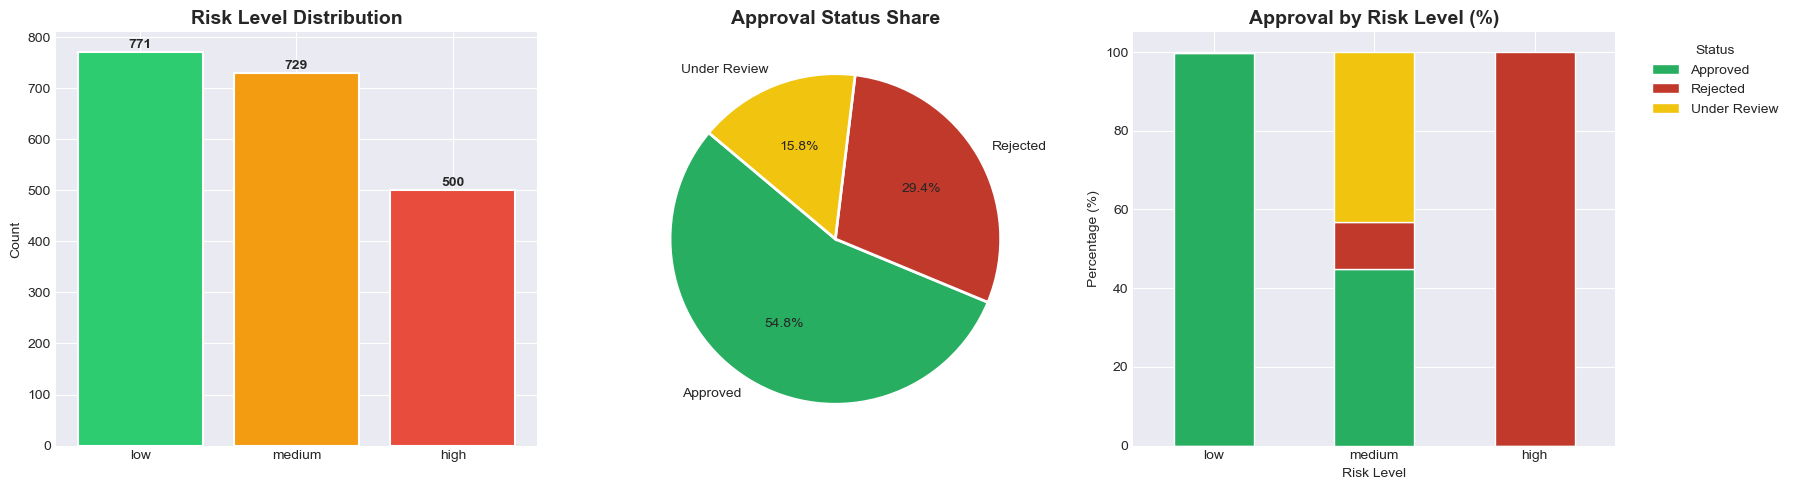

✅ Saved → outputs/risk_approval_distribution.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Risk level bar chart
risk_counts = df['risk_level'].value_counts().reindex(['low', 'medium', 'high'])
bars = axes[0].bar(risk_counts.index, risk_counts.values,
                   color=[RISK_COLORS[r] for r in risk_counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# Approval status pie
approval_counts = df['approval_status'].value_counts()
axes[1].pie(approval_counts.values, labels=approval_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=[APPROVAL_COLORS[a] for a in approval_counts.index],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Approval Status Share', fontsize=14, fontweight='bold')

# Risk × Approval stacked bar
cross = pd.crosstab(df['risk_level'], df['approval_status'], normalize='index') * 100
cross = cross.reindex(['low', 'medium', 'high'])
cross.plot(kind='bar', ax=axes[2], stacked=True,
           color=[APPROVAL_COLORS[c] for c in cross.columns],
           edgecolor='white')
axes[2].set_title('Approval by Risk Level (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xlabel('Risk Level')
axes[2].legend(title='Status', bbox_to_anchor=(1.05, 1))
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('outputs/risk_approval_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/risk_approval_distribution.png')

## 2.2 Credit Score Analysis by Risk Level

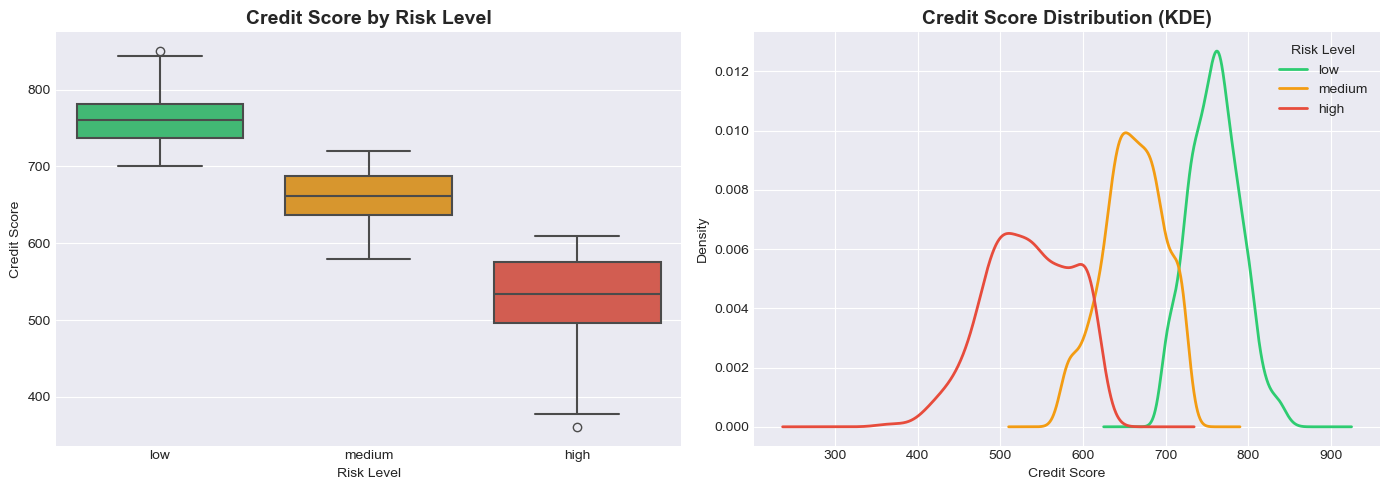

✅ Saved → outputs/credit_score_by_risk.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
order = ['low', 'medium', 'high']
palette = [RISK_COLORS[r] for r in order]
sns.boxplot(data=df, x='risk_level', y='credit_score', order=order,
            palette=palette, ax=axes[0], linewidth=1.5)
axes[0].set_title('Credit Score by Risk Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Credit Score')

# KDE plot
for risk in order:
    subset = df[df['risk_level'] == risk]['credit_score']
    subset.plot.kde(ax=axes[1], label=risk, color=RISK_COLORS[risk], linewidth=2)
axes[1].set_title('Credit Score Distribution (KDE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].legend(title='Risk Level')

plt.tight_layout()
plt.savefig('outputs/credit_score_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/credit_score_by_risk.png')

## 2.3 Income, Loan Amount & Debt-to-Income Ratio

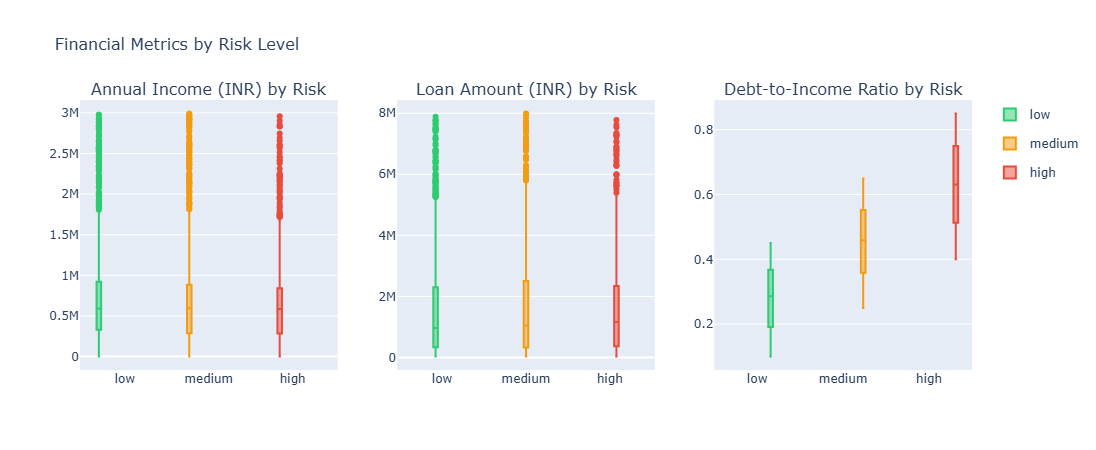

✅ Saved → outputs/financial_metrics_by_risk.html


In [4]:
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Annual Income (INR) by Risk',
                                    'Loan Amount (INR) by Risk',
                                    'Debt-to-Income Ratio by Risk'])

for i, col in enumerate(['annual_income_inr', 'loan_amount_inr', 'debt_to_income_ratio'], 1):
    for risk in ['low', 'medium', 'high']:
        vals = df[df['risk_level'] == risk][col]
        fig.add_trace(
            go.Box(y=vals, name=risk, marker_color=RISK_COLORS[risk],
                   showlegend=(i == 1), legendgroup=risk),
            row=1, col=i
        )

fig.update_layout(title='Financial Metrics by Risk Level',
                  title_font_size=16, height=450, boxmode='group')
fig.write_html('outputs/financial_metrics_by_risk.html')
fig.show()
print('✅ Saved → outputs/financial_metrics_by_risk.html')

## 2.4 Loan Purpose vs Risk Level Heatmap

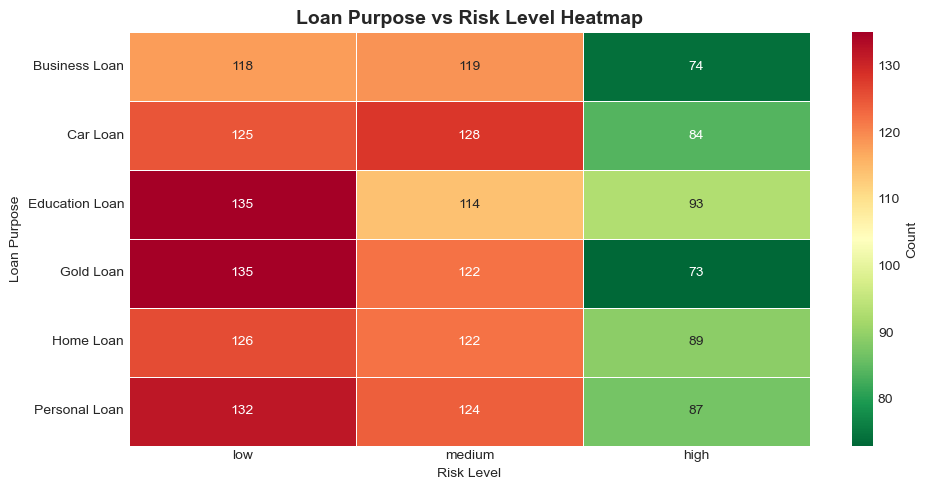

✅ Saved → outputs/loan_purpose_heatmap.png


In [5]:
pivot = df.pivot_table(index='loan_purpose', columns='risk_level',
                       values='applicant_id', aggfunc='count', fill_value=0)
pivot = pivot[['low', 'medium', 'high']]

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Loan Purpose vs Risk Level Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Loan Purpose')
plt.xlabel('Risk Level')
plt.tight_layout()
plt.savefig('outputs/loan_purpose_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/loan_purpose_heatmap.png')

## 2.5 Employment Type vs Risk

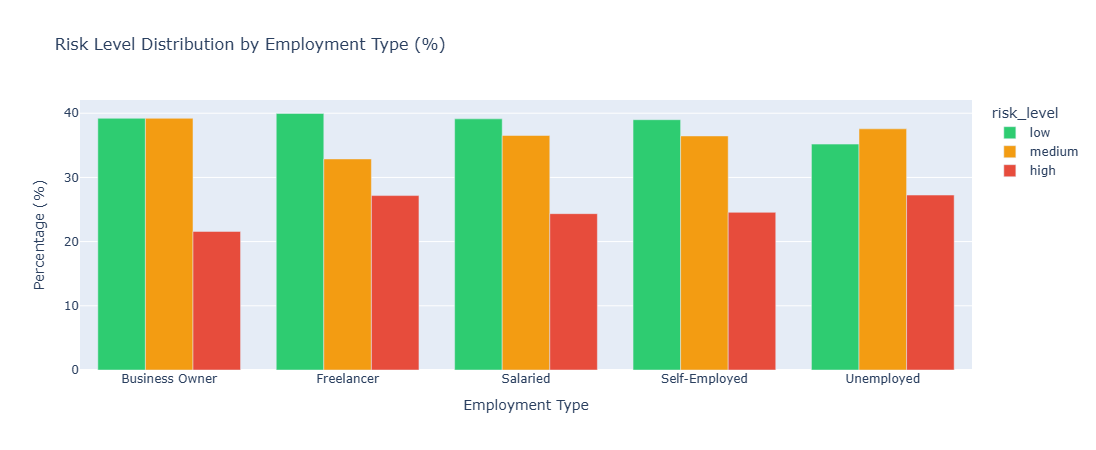

✅ Saved → outputs/employment_vs_risk.html


In [6]:
emp_risk = df.groupby(['employment_type', 'risk_level']).size().unstack(fill_value=0)
emp_risk_pct = emp_risk.div(emp_risk.sum(axis=1), axis=0) * 100

fig = px.bar(
    emp_risk_pct.reset_index().melt(id_vars='employment_type', var_name='risk_level', value_name='pct'),
    x='employment_type', y='pct', color='risk_level',
    color_discrete_map=RISK_COLORS,
    title='Risk Level Distribution by Employment Type (%)',
    labels={'pct': 'Percentage (%)', 'employment_type': 'Employment Type'},
    barmode='group', height=450,
    category_orders={'risk_level': ['low', 'medium', 'high']}
)
fig.update_layout(title_font_size=16)
fig.write_html('outputs/employment_vs_risk.html')
fig.show()
print('✅ Saved → outputs/employment_vs_risk.html')

## 2.6 Correlation Matrix (Numerical Features)

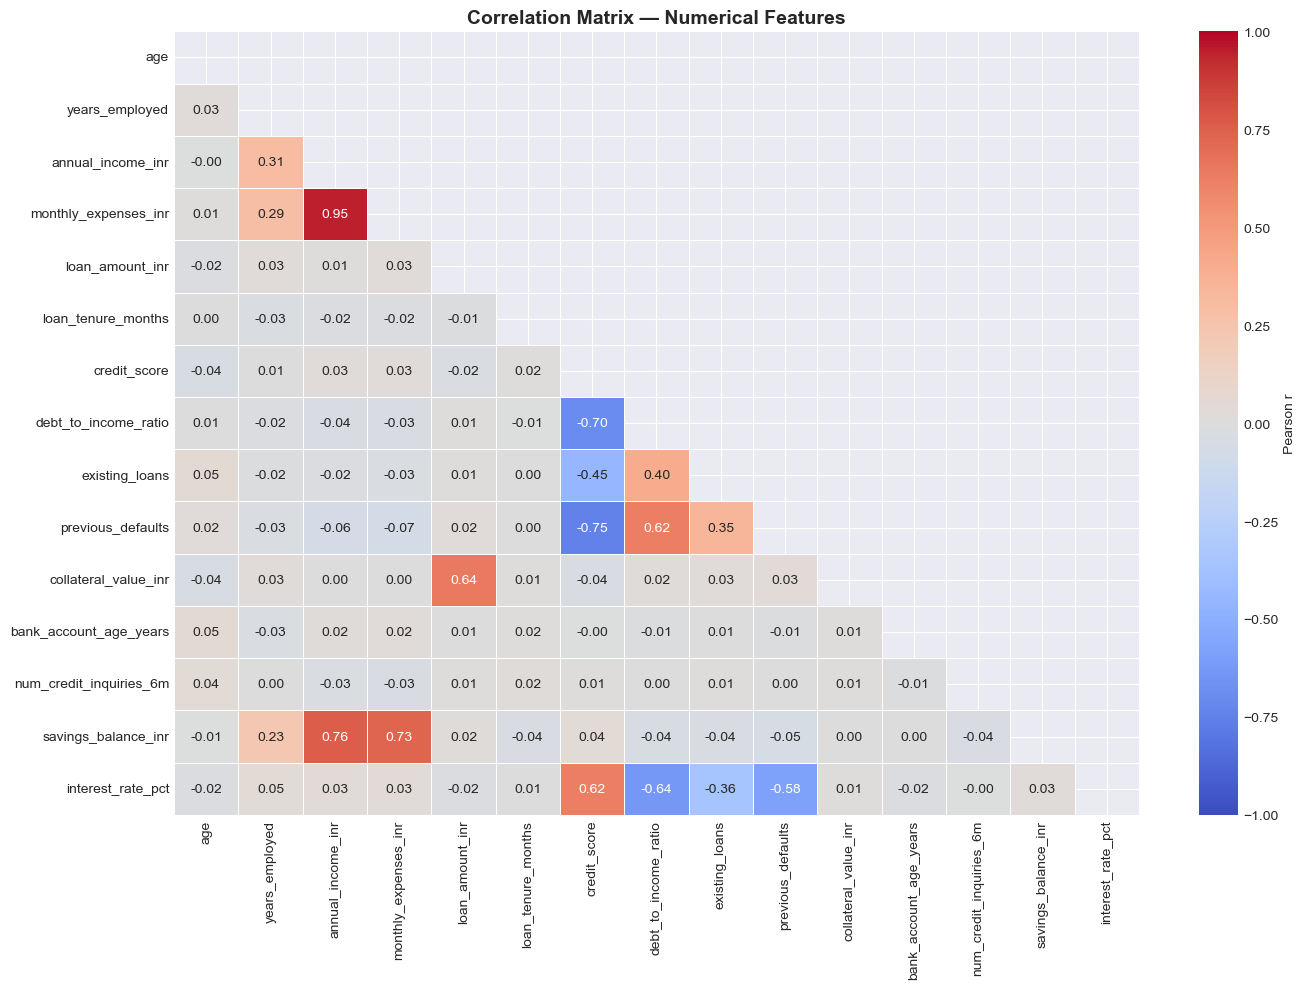

✅ Saved → outputs/correlation_matrix.png


In [7]:
num_cols = ['age', 'years_employed', 'annual_income_inr', 'monthly_expenses_inr',
            'loan_amount_inr', 'loan_tenure_months', 'credit_score',
            'debt_to_income_ratio', 'existing_loans', 'previous_defaults',
            'collateral_value_inr', 'bank_account_age_years',
            'num_credit_inquiries_6m', 'savings_balance_inr', 'interest_rate_pct']

corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/correlation_matrix.png')

## 2.7 Temporal Trend — Applications Over Time

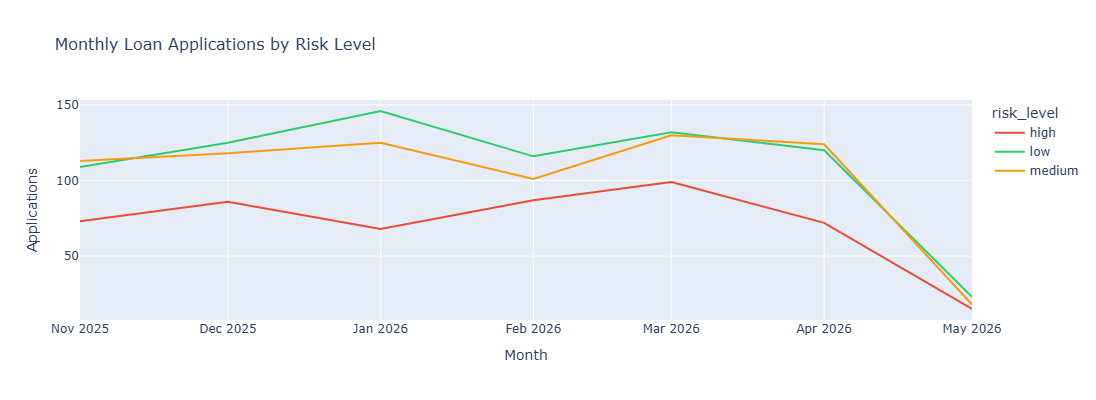

✅ Saved → outputs/monthly_trend.html


In [8]:
monthly = (df.groupby([df['application_date'].dt.to_period('M'), 'risk_level'])
             .size()
             .reset_index(name='count'))
monthly['application_date'] = monthly['application_date'].dt.to_timestamp()

fig = px.line(
    monthly, x='application_date', y='count', color='risk_level',
    color_discrete_map=RISK_COLORS,
    title='Monthly Loan Applications by Risk Level',
    labels={'count': 'Applications', 'application_date': 'Month'},
    height=400
)
fig.update_traces(line_width=2)
fig.update_layout(title_font_size=16)
fig.write_html('outputs/monthly_trend.html')
fig.show()
print('✅ Saved → outputs/monthly_trend.html')

## 2.8 Geographic Distribution — Top States

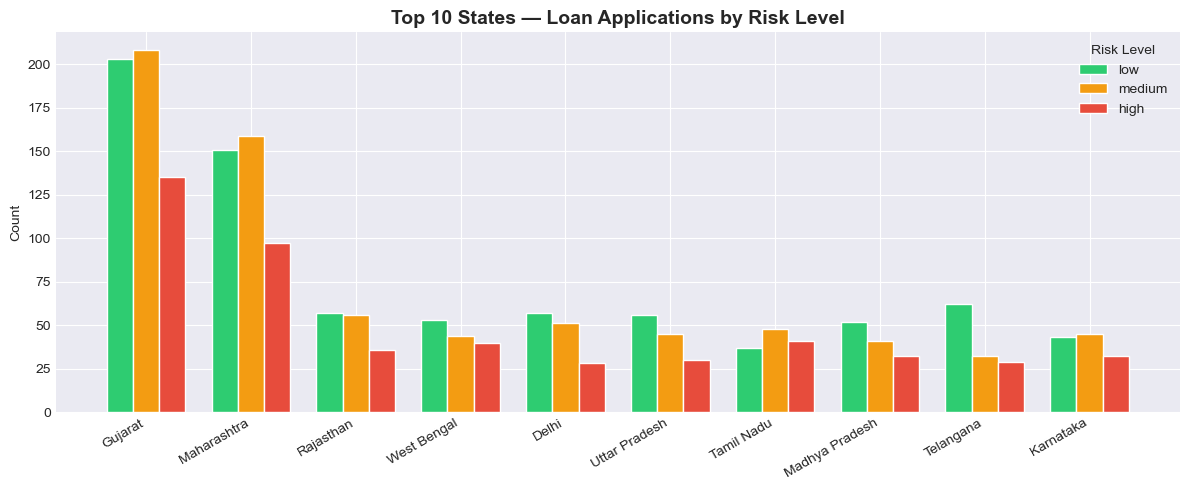

✅ Saved → outputs/state_distribution.png


In [9]:
state_risk = df.groupby(['state', 'risk_level']).size().unstack(fill_value=0)
state_risk['total'] = state_risk.sum(axis=1)
state_risk['high_pct'] = (state_risk.get('high', 0) / state_risk['total'] * 100).round(1)
top_states = state_risk.nlargest(10, 'total')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top_states))
width = 0.25
for i, risk in enumerate(['low', 'medium', 'high']):
    if risk in top_states.columns:
        ax.bar(x + i * width, top_states[risk], width,
               label=risk, color=RISK_COLORS[risk], edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(top_states.index, rotation=30, ha='right')
ax.set_title('Top 10 States — Loan Applications by Risk Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(title='Risk Level')
plt.tight_layout()
plt.savefig('outputs/state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/state_distribution.png')

## 2.9 Age Group & Gender Analysis

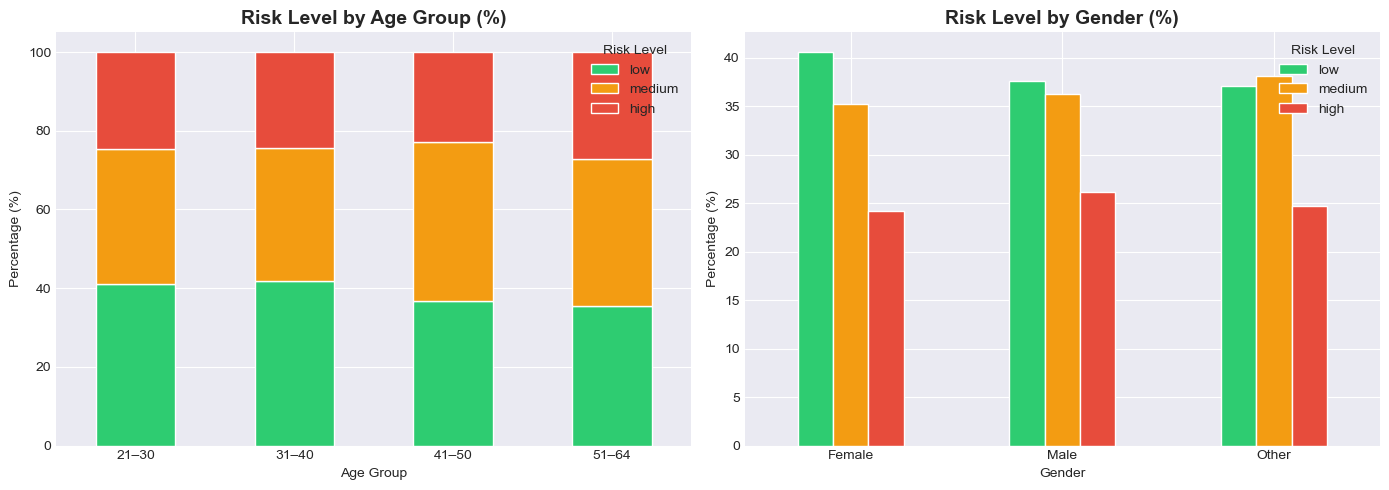

✅ Saved → outputs/demographics_vs_risk.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group vs risk
age_risk = df.groupby(['age_group', 'risk_level']).size().unstack(fill_value=0)
age_risk = age_risk[['low', 'medium', 'high']]
age_risk_pct = age_risk.div(age_risk.sum(axis=1), axis=0) * 100
age_risk_pct.plot(kind='bar', ax=axes[0], color=[RISK_COLORS[r] for r in ['low','medium','high']],
                  edgecolor='white', stacked=True)
axes[0].set_title('Risk Level by Age Group (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Risk Level')

# Gender vs risk
gen_risk = df.groupby(['gender', 'risk_level']).size().unstack(fill_value=0)
gen_risk = gen_risk.get(['low', 'medium', 'high'], gen_risk)
gen_risk_pct = gen_risk.div(gen_risk.sum(axis=1), axis=0) * 100
gen_risk_pct.plot(kind='bar', ax=axes[1], color=[RISK_COLORS[r] for r in ['low','medium','high']],
                  edgecolor='white')
axes[1].set_title('Risk Level by Gender (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Risk Level')

plt.tight_layout()
plt.savefig('outputs/demographics_vs_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/demographics_vs_risk.png')

## 2.10 Interest Rate KPI by Risk Level

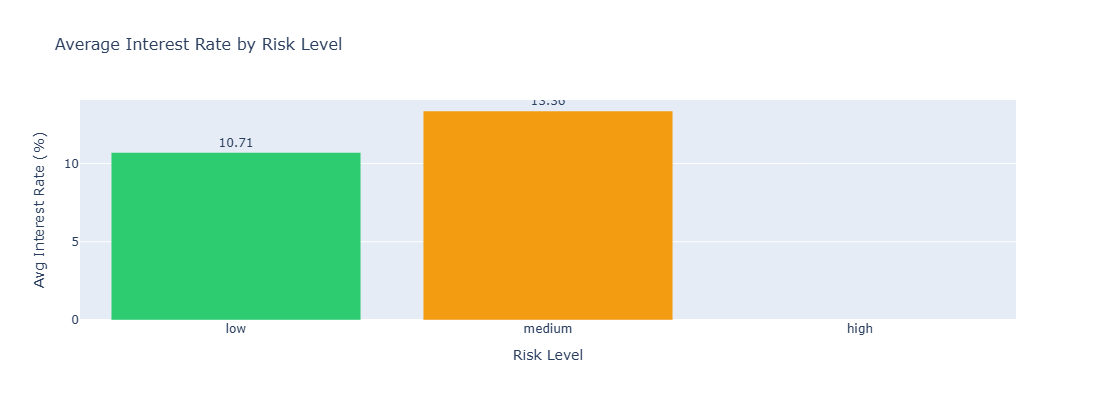

Risk Level  Avg Interest Rate (%)
       low                  10.71
    medium                  13.36
      high                    NaN

✅ All EDA visualizations saved in outputs/


In [11]:
rate_summary = (df[df['interest_rate_pct'] > 0]
                .groupby('risk_level')['interest_rate_pct']
                .mean().round(2)
                .reindex(['low', 'medium', 'high'])
                .reset_index())
rate_summary.columns = ['Risk Level', 'Avg Interest Rate (%)']

fig = px.bar(rate_summary, x='Risk Level', y='Avg Interest Rate (%)',
             color='Risk Level', color_discrete_map=RISK_COLORS,
             text='Avg Interest Rate (%)',
             title='Average Interest Rate by Risk Level',
             height=400)
fig.update_traces(textposition='outside')
fig.update_layout(title_font_size=16, showlegend=False)
fig.write_html('outputs/interest_rate_by_risk.html')
fig.show()
print(rate_summary.to_string(index=False))
print('\n✅ All EDA visualizations saved in outputs/')